# Neural Networks
## In this Lesson
* What is a Neural Networks
* London Cycle Hire Data
* How does a Neural Network Work?
* Vectors and Matrices
* Dot Product
* Activation Functions
* Loss Functions
* Back Propogation
* Python Example
* Genetic Algorithms
* NEAT

# What is a Neural Network?
In data science, an artificial neural network (commonly referred to as simply a "neural network") is a type of machine learning algorithm which can be used for supervised problems.

Artificial neural networks have been around since the 1800s, although in their simplest form, neural networks become linear regression. It wasn't until the 1940s that researchers took direct inspiration from biological systems when designing them. The key takeaway is that neural networks as a mathematical approach is not new, but advents in computer processing power have enabled deep learning and large language models.


# London Cycle Hire Data
For this session, we will be using a London bike hire data set [sourced from Kaggle](https://www.kaggle.com/datasets/hmavrodiev/london-bike-sharing-dataset). For convenience, the data is included in this Git repository.

Firstly, let us load the data using python to inspect.

In [33]:
# Pandas to read the data
import pandas as pd
# Display function to view data
from IPython.display import display

# Read excel
df = pd.read_csv("../data/london_cycle_hire.csv")

# Display
display(df)

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...
17409,2017-01-03 19:00:00,1042,5.0,1.0,81.0,19.0,3.0,0.0,0.0,3.0
17410,2017-01-03 20:00:00,541,5.0,1.0,81.0,21.0,4.0,0.0,0.0,3.0
17411,2017-01-03 21:00:00,337,5.5,1.5,78.5,24.0,4.0,0.0,0.0,3.0
17412,2017-01-03 22:00:00,224,5.5,1.5,76.0,23.0,4.0,0.0,0.0,3.0


As you can see, the data contains the count of total cycles hired for a range of days between 2015 and 2017, combined with weather and other contextual information, such as holidays and weekends.

We want to be able to predict the total cycle hire, given these other factors.


# Sci-Kit Learn Example
If we want to use a neural network to predict the number of cycle hires, we can use Sci-Kit Learn to provide a model. This may be how you would look to use a neural network at a customer (rather than building your own code to train and execute one).

In [35]:

# Import our Neural Network Model (for regression problems)
from sklearn.neural_network import MLPRegressor
# Import a normaliser
from sklearn.preprocessing import MinMaxScaler
# Import r2 score to assess accuracy
from sklearn.metrics import r2_score

# It makes sense to normalise data before we pass it to an ANN
numeric_cols = df.select_dtypes(include='number').columns
scaler = MinMaxScaler()
normalized_array = scaler.fit_transform(df[numeric_cols])
normalized_df = pd.DataFrame(normalized_array, columns=numeric_cols)

# Split our data at 70%
# Question: Why does it not make sense to use a random split method for this data?
split_point = int(len(normalized_df)*0.7)
train = df[:split_point]
test = df[split_point:]

# Variable for the features we will train with
features = ["t1", "t2", "hum", "wind_speed", "weather_code", "is_holiday", "is_weekend", "season"]

# Define our model object, including some hyperparameters
ann = MLPRegressor(
    hidden_layer_sizes=(10, 5, 3,),
    activation = "relu"
)

# Fit model
ann.fit(train[features], train["cnt"])

# Use model to predict
predictions = ann.predict(test[features])

# Evaluate model using r2
print("r2 score:")
print(r2_score(test["cnt"], predictions))



r2 score:
0.23132580703915517


C:\Users\jlawton\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


An R2 score of 0.25 is respectable, in practice we should expect to be able to improve this with further feature engineering and/or more hidden nodes. In our [multilinear regression lesson](https://github.com/Jack-Lawton/python-resources/blob/main/lessons/Multilinear%20Regression.ipynb), we reached an R2 of over 0.5 on the same data set (over weekend data only).

For more information on hyperparameters available for this neural network, refer to the [Sci-Kit Learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html#sklearn.neural_network.MLPRegressor).

# How Does a Neural Network Work?
When implementing any machine learning algorithm, it's useful to know how it works. Neural networks are no different. Let's dive into them and derive our own without using Sci-Kit Learn.

First, what does a neural network look like? Let's visualise the one we just trained.

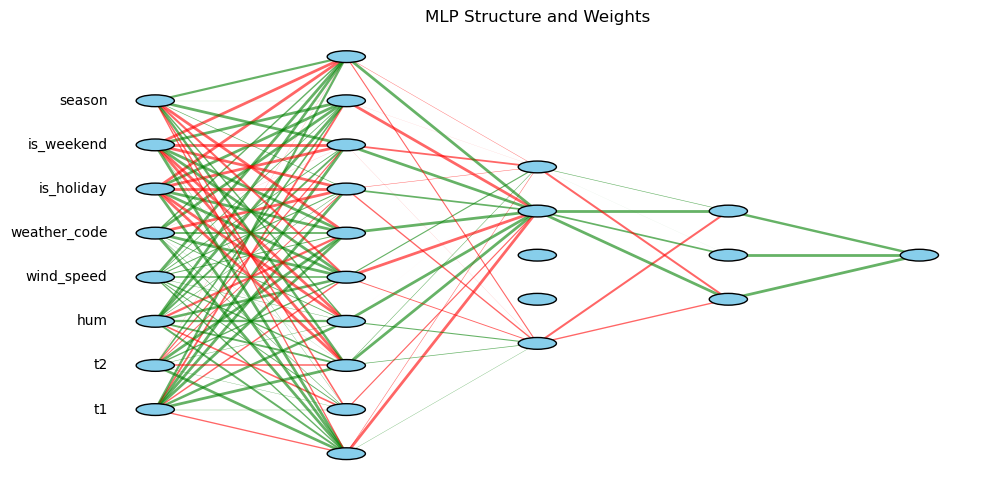

In [21]:
import matplotlib.pyplot as plt
import numpy as np


# Function to plot a neural network (thanks to ChatGPT)
def plot_mlp_structure(mlp, feature_names=None):
    layer_sizes = [coefs.shape[0] for coefs in mlp.coefs_] + [mlp.coefs_[-1].shape[1]]
    fig, ax = plt.subplots(figsize=(10, 5))

    # Coordinates
    layer_count = len(layer_sizes)
    y_spacing = 1.5
    x_spacing = 2

    node_positions = {}
    for i, layer_size in enumerate(layer_sizes):
        x = i * x_spacing
        for j in range(layer_size):
            y = j * y_spacing - (layer_size - 1) * y_spacing / 2
            node_positions[(i, j)] = (x, y)
            ax.add_patch(plt.Circle((x, y), 0.2, color='skyblue', ec='black', zorder=3))
            if i == 0 and feature_names:
                ax.text(x - 0.5, y, feature_names[j], ha='right', va='center')

    # Draw connections with weight color
    for i, (layer_weights, layer_biases) in enumerate(zip(mlp.coefs_, mlp.intercepts_)):
        for j, from_node in enumerate(layer_weights):
            for k, weight in enumerate(from_node):
                x1, y1 = node_positions[(i, j)]
                x2, y2 = node_positions[(i+1, k)]
                color = 'red' if weight < 0 else 'green'
                linewidth = min(1.0, abs(weight)) * 2
                ax.plot([x1, x2], [y1, y2], color=color, linewidth=linewidth, alpha=0.6, zorder=1)

    ax.axis('off')
    ax.set_title("MLP Structure and Weights")
    plt.tight_layout()
    plt.show()
    
    
plot_mlp_structure(ann, feature_names=features)

Here we can see the neural network has 7 input nodes and 1 output node, between are 3 hidden layers with 10, 5 and 3 nodes. The size and colour of the lines between each node show the strength and sign of the weights between them.

Let's discuss the maths behind a neural network, as an example we can use this simplified network with 3 input nodes, a 4 node hidden layer and 2 output nodes.

<p><img align="center" width="50%" src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/46/Colored_neural_network.svg/800px-Colored_neural_network.svg.png"></p><br>

Let's define our three layers as vectors. Input layer, $\boldsymbol{i}$, hidden layer, $\boldsymbol{h}$ and output layer $\boldsymbol{\omega}$.

$\boldsymbol{i} = \begin{bmatrix}
i_1 & i_2 & i_3
\end{bmatrix}$

$\boldsymbol{h} = \begin{bmatrix}
h_1 & h_2 & h_3 & h_4
\end{bmatrix}$

$\boldsymbol{\omega} = \begin{bmatrix}
\omega_1 & \omega_2
\end{bmatrix}$

Between each layer every node has a weight to every other node. These weights can be described as matrices.

$\mathbf{W}_{ih} = 
\begin{bmatrix}
W_{ih11} & W_{ih12} & W_{ih13} & W_{ih14} \\
W_{ih21} & W_{ih22} & W_{ih23} & W_{ih24} \\
W_{ih31} & W_{ih32} & W_{ih33} & W_{ih34}
\end{bmatrix}$

$\mathbf{W}_{h\omega} = 
\begin{bmatrix}
W_{h\omega11} & W_{h\omega12}\\
W_{h\omega21} & W_{h\omega22}\\
W_{h\omega31} & W_{h\omega32}\\
W_{h\omega41} & W_{h\omega42}
\end{bmatrix}$

Note $\mathbf{W}_{ih}$ is a 3x4 matrix as there are 3 nodes in the input and 4 in the hidden layer. The same is true for $\mathbf{W}_{h\omega}$ between the hidden layer and output layer (4x2).

To calculate the first node in the hidden layer (as an example), we would need to multiply the input nodes by the weights connecting them to the first hidden node, i.e.

$h_1 = f(i_1W_{ih11} + i_2W_{ih21} + i_3W_{ih31})$

Where $f$ is the activation function (we will get to this).

## Dot Product

We can use the matrix dot product to simplify our mathematical expressions here. In a simple case, the dot product means:
$
\begin{bmatrix}
a_{1} & a_{2}
\end{bmatrix}
\cdot
\begin{bmatrix}
b_{11} & b_{12} & b_{13} \\
b_{21} & b_{22} & b_{23}
\end{bmatrix}
=
\begin{bmatrix}
a_{1}b_{11} + a_{2}b_{21} & a_{1}b_{12} + a_{2}b_{22} & a_{1}b_{13} + a_{2}b_{23}
\end{bmatrix}$

Meaning,

$\boldsymbol{h} = f(\boldsymbol{i}\cdot\mathbf{W}_{ih})$

and

$\boldsymbol{\omega} = f(\boldsymbol{h}\cdot\mathbf{W}_{h\omega})$

Note, this is just mathematical convenience, the underlying logic that all the weights are applied and multipled through is still true. I have also used identical activation functions for both the hidden and output layers, they can be different.

# Activation Functions
Activation functions are a key component of modern artificial neural networks and allow the networks to learn more complex patterns by introducing non-linearity across nodes.

An activation function is a mathematical function applied to the signal into a node (previous layer x weight). Individual layers and nodes can have different, unique activation functions. However, for simplicity, we will consider our neural network to have only one, such that,

$\boldsymbol{h} = f(\boldsymbol{i}\cdot\mathbf{W}_{ih})$

i.e.

$h_1 = f(i_1W_{ih11} + i_2W_{ih21} + i_3W_{ih31})$

$h_2 = f(i_1W_{ih12} + i_2W_{ih22} + i_3W_{ih32})$

etc.

The simplest activation function is the identity function,

$f(x) = x$

With the identity activation function, neural networks behave like linear regressors.

A popular activation function is ReLU (Rectified linear unit),

$\text{ReLU}(x) = 
\begin{cases}
0 & \text{if } x < 0 \\
x & \text{if } x \geq 0
\end{cases}$ 

ReLU is useful to allow the network to behave more dynamically, if the input becomes negative, it essentially deactivates the neuron, consider it like flipping a switch. ReLU is also simple to compute and differentiate, making training easier.

Many other activation functions [are available](https://en.wikipedia.org/wiki/Activation_function#Table_of_activation_functions) and can be used in conjunction for maximum value.


## Exercise
Write python functions for the ReLU activation function and its differential.

### Solution

In [4]:


def relu(x: float) -> float:
    if x >= 0:
        return x
    else:
        return 0.0


def dif_relu(x: float) -> float:
    if x >= 0:
        return 1.0
    else:
        return 0.0


# Loss Functions

To train any machine learning model, we need a loss function.

## Discuss

What is a loss function?


### Answer

A loss function is a measure for how good our model is. The larger our loss function, the worse our model.

You should be familiar with Mean Square Error from [linear regression](https://github.com/Jack-Lawton/python-resources/blob/main/lessons/Regression.ipynb).

## Exercise

Define a function for Mean Square Error, where we know the mean.


In [3]:

mean_y = 5.5

def mean_square_error(y):
    # TODO: Complete
    return None


### Solution



In [ ]:

mean_y = 5.5

def mean_square_error(y):
    return 0.5 * (mean - y) ** 2



i.e. our MSE function is

$L(y) = \frac{1}{2}(\hat{y}-y)^2$

## Question

What is the differential of the MSE loss function?


### Answer

$\frac{\partial L}{\partial y} = \hat{y} - y$

Or, for the output layer on our neural network,

$\frac{\partial L}{\partial \boldsymbol{\omega}} = \hat{\boldsymbol{\omega}} - \boldsymbol{\omega}$



# Backpropogation

It is important that we know the differential of the activation function so we can perform the training process known as backpropogation.

To train a neural network is to use a set of known input and output layer pairs to estimate what the correct weights between must be.

To understand backpropogation, consider our output layer,

$\boldsymbol{\omega} = f(\boldsymbol{h}\cdot\mathbf{W}_{h\omega})$

Let's define $\boldsymbol{z}$ as the weighted input to that layer, i.e.

$\boldsymbol{z} = \boldsymbol{h}\cdot\mathbf{W}_{h\omega}$

$\boldsymbol{\omega} = f(\boldsymbol{z})$

If we know the differential of our activation function, $f'(x)$, we can say,

$\frac{\partial\boldsymbol{\omega}}{\partial\boldsymbol{z}} = f'(\boldsymbol{z})$

Then, using the differential of the loss function and the [chain rule](https://en.wikipedia.org/wiki/Chain_rule), we can define the rate of change of the loss function with respect to our weighted input

$\frac{\partial L}{\partial\boldsymbol{z}} = \frac{\partial\boldsymbol{\omega}}{\partial\boldsymbol{z}}\frac{\partial L}{\partial\boldsymbol{\omega}}$

For convenience, we define the change in the loss function for this layer as the vector $\boldsymbol{\delta}_\omega$,

$\boldsymbol{\delta}_\omega = \frac{\partial L}{\partial\boldsymbol{z}} = \frac{\partial\boldsymbol{\omega}}{\partial\boldsymbol{z}}\frac{\partial L}{\partial\boldsymbol{\omega}}$

Differentiating $\boldsymbol{z}$ with respect to $\mathbf{W}_{h\omega}$ gives

$\frac{\partial\boldsymbol{z}}{\partial\mathbf{W}_{h\omega}} = \boldsymbol{h}^T$

* N.B, the above is not strictly correct as $\frac{\partial\boldsymbol{z}}{\partial\mathbf{W}_{h\omega}}$ is a tensor, but for our purposes simplifies to $\boldsymbol{h}^T$ when calculated through.

Meaning, again via the chain rule,

$\frac{\partial L}{\partial\mathbf{W}_{h\omega}} = \frac{\partial L}{\partial\boldsymbol{z}}\frac{\partial\boldsymbol{z}}{\partial\mathbf{W}_{h\omega}} = \boldsymbol{\delta}_\omega\cdot\boldsymbol{h}^T$

This is true for every layer of the neural network, i.e.

$\frac{\partial L}{\partial\mathbf{W}_{ih}} = \boldsymbol{\delta}_h\cdot\boldsymbol{i}^T$

Where

$\boldsymbol{\delta}_h = \frac{\partial L}{\partial \boldsymbol{h}} = \frac{\partial \boldsymbol{z}}{\partial \boldsymbol{h}}\frac{\partial L}{\partial\boldsymbol{z}} = (\mathbf{W}_{h\omega})^T\cdot\boldsymbol{\delta}_\omega$

Generally, $\frac{\partial L}{\partial\mathbf{W}_{ab}}$ is the gradient of the weights between generic layers $a$ and $b$. It represents the opposite of the direction we must adjust the weights so that the output of the neural network approaches its expectation value, $\boldsymbol{\omega} \approx \hat{\boldsymbol{\omega}}$. When training a machine learning model, we use a learning rate, $\eta$ to incrementally adjust the weight towards the optimum.

$\mathbf{W}_{h\omega_{NEW}} = \mathbf{W}_{h\omega} - \eta\frac{\partial L}{\partial\mathbf{W}_{h\omega}} = \mathbf{W}_{h\omega} - \eta(\boldsymbol{\delta}_\omega\cdot\boldsymbol{h}^T)$


## Python Implementation
Below, I have prepared a simple python implentation of a Neural Network with backpropogation implemented in the `train()` function.

In [29]:

import numpy as np
from typing import Callable, Iterable

class ArtificialNeuralNetwork:
    def __init__(
        self,
        inputs: int,
        hidden_layers: tuple[int],
        outputs: int,
        activation_function: Callable[[np.ndarray], np.ndarray],
        activation_derivative: Callable[[np.ndarray], np.ndarray]
    ):
        self.layer_sizes = [inputs] + list(hidden_layers) + [outputs]
        self.activation_function = activation_function
        self.activation_derivative = activation_function
        self.weights: list[np.ndarray] = []
        
        # Initialise weight matrices with small random values for learning
        for i in range(len(self.layer_sizes) - 1):
            weight_matrix = np.random.randn(self.layer_sizes[i + 1], self.layer_sizes[i]) * 0.01
            self.weights.append(weight_matrix)

    def predict(self, input_data: Iterable[float]) -> np.ndarray:
        activation = np.array(input_data).reshape(-1, 1)

        for weight_matrix in self.weights:
            activation = np.dot(weight_matrix, activation)
            activation = self.activation_function(activation)

        return activation
    
    def train(
        self,
        input_data: Iterable[float],
        target_data: Iterable[float],
        learning_rate: float = 0.01
    ) -> None:
        # Forward pass: store activations and z-values
        activation = np.array(input_data).reshape(-1, 1)
        activations = [activation]
        zs = []

        for weight_matrix in self.weights:
            z = np.dot(weight_matrix, activation)
            zs.append(z)
            activation = self.activation_function(z)
            activations.append(activation)

        # Compute output error (dL/dz) using MSE loss derivative
        target = np.array(target_data).reshape(-1, 1)
        error = activations[-1] - target
        delta = error * self.activation_derivative(zs[-1])  # dL/dz for output layer

        # Backward pass: compute gradients and update weights
        deltas = [delta]
        for l in range(2, len(self.layer_sizes)):
            z = zs[-l]
            sp = self.activation_derivative(z)
            delta = np.dot(self.weights[-l + 1].T, deltas[-1]) * sp
            deltas.append(delta)
        deltas.reverse()

        # Gradient descent step
        for i in range(len(self.weights)):
            self.weights[i] -= learning_rate * np.dot(deltas[i], activations[i].T)

The below code demonstrates how to use the network, note how I have to train on examples over many epochs for the weights to approach the correct values.

In [32]:

# Activation: sigmoid and its derivative
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x: np.ndarray) -> np.ndarray:
    s = sigmoid(x)
    return s * (1 - s)

ann = ArtificialNeuralNetwork(inputs=2, hidden_layers=(6,), outputs=1,
                              activation_function=sigmoid,
                              activation_derivative=sigmoid_derivative)

# Train on a simple example: XOR
for epoch in range(20_000):
    ann.train([0, 0], [0], learning_rate=0.5)
    ann.train([1, 0], [1], learning_rate=0.5)
    ann.train([0, 1], [1], learning_rate=0.5)
    ann.train([1, 1], [0], learning_rate=0.5)

# Test
print("0 XOR 1:", ann.predict([0, 1]))
print("1 XOR 0:", ann.predict([1, 0]))
print("0 XOR 0:", ann.predict([0, 0]))
print("1 XOR 1:", ann.predict([1, 1]))



0 XOR 1: [[0.99909115]]
1 XOR 0: [[0.99874984]]
0 XOR 0: [[0.02382871]]
1 XOR 1: [[0.04289676]]


As you can see, the outputs of the neural network approach what we would expect for XOR.

# Genetic Algorithms

## Question
What is a genetic algorithm?

## Answer
A machine learning technique to determine optimum hyperparameters by emulating the process of natural selection & evolution.

## Question #2
What are key concepts in an genetic algorithm, discuss

## Answer #2
* Generations
* Mutation
* Genome crossover 
* Fitness function
* ... More!

# NEAT

NEAT, or NeuroEvolution of Augmenting Topologies is an approach specifically for using a genetic algorithms to evolve neural networks. It's very popular for training neural networks to interact with sophisticated systems, requiring multiple outputs, such as playing a video game.

Conveniently, there is also a python library for NEAT.

`pip install neat-python`

Below is a quick example of how you could train NEAT to solve for XOR.


In [39]:
import neat

# XOR dataset
xor_inputs = [(0.0, 0.0), (0.0, 1.0), (1.0, 0.0), (1.0, 1.0)]
xor_outputs = [0.0, 1.0, 1.0, 0.0]

def eval_genomes(genomes, config):
    for genome_id, genome in genomes:
        net = neat.nn.FeedForwardNetwork.create(genome, config)
        total_error = 0.0
        for xi, xo in zip(xor_inputs, xor_outputs):
            output = net.activate(xi)[0]
            total_error += (output - xo) ** 2
        genome.fitness = 4 - total_error  # Higher is better

        
config = neat.Config(
    neat.DefaultGenome,
    neat.DefaultReproduction,
    neat.DefaultSpeciesSet,
    neat.DefaultStagnation,
    "../miscellaneous/neat_xor_config.txt"
)

pop = neat.Population(config)
pop.add_reporter(neat.StdOutReporter(True))
stats = neat.StatisticsReporter()
pop.add_reporter(stats)

winner = pop.run(eval_genomes, 100)

print('\nBest genome:\n{!s}'.format(winner))

winner_net = neat.nn.FeedForwardNetwork.create(winner, config)
for xi in xor_inputs:
    output = winner_net.activate(xi)
    print(f"Input {xi} → {output}")


 ****** Running generation 0 ****** 

Population's average fitness: 2.20653 stdev: 0.31868
Best fitness: 2.93017 - size: (1, 2) - species 1 - id 107
Average adjusted fitness: 0.579
Mean genetic distance 1.448, standard deviation 0.523
Population of 150 members in 1 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
     1    0   150      2.9    0.579     0
Total extinctions: 0
Generation time: 0.003 sec

 ****** Running generation 1 ****** 

Population's average fitness: 2.32034 stdev: 0.33491
Best fitness: 2.99782 - size: (1, 2) - species 1 - id 165
Average adjusted fitness: 0.547
Mean genetic distance 1.623, standard deviation 0.720
Population of 150 members in 2 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
     1    1   142      3.0    0.547     0
     2    0     8       --       --     0
Total extinctions: 0
Generation time: 0.021 sec (0.012 average)

 ****** Running generation 2 ****** 

Pop

Mean genetic distance 2.770, standard deviation 1.352
Population of 150 members in 3 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
     1   21    61      3.0    0.632     0
     2   20    48      3.0    0.603     0
     3    6    41      3.0    0.777     0
Total extinctions: 0
Generation time: 0.038 sec (0.039 average)

 ****** Running generation 22 ****** 

Population's average fitness: 2.49726 stdev: 0.53600
Best fitness: 3.00001 - size: (2, 4) - species 1 - id 3279
Average adjusted fitness: 0.752
Mean genetic distance 2.710, standard deviation 1.380
Population of 150 members in 3 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
     1   22    56      3.0    0.719     0
     2   21    41      3.0    0.748     0
     3    7    53      3.0    0.789     0
Total extinctions: 0
Generation time: 0.040 sec (0.040 average)

 ****** Running generation 23 ****** 

Population's average fitness: 2.53114 st

You can see, as before, the best genome produces outputs which approach the correct values of 1 and 0 for an XOR operation.

We can also visualise the training process over generations,

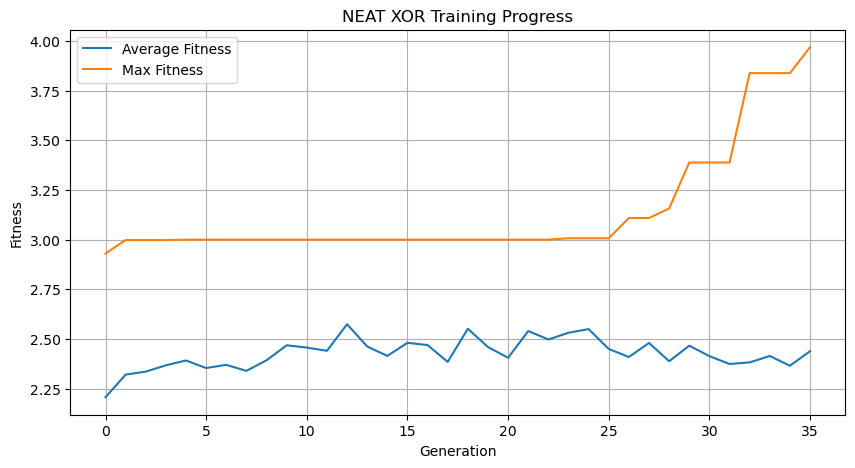

In [41]:
import matplotlib.pyplot as plt

best_fitness = stats.get_fitness_mean()
max_fitness = stats.get_fitness_stat(max)
generations = range(len(best_fitness))

plt.figure(figsize=(10, 5))
plt.plot(generations, best_fitness, label="Average Fitness")
plt.plot(generations, max_fitness, label="Max Fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("NEAT XOR Training Progress")
plt.legend()
plt.grid(True)
plt.show()

And, we can visualise the winning genome (neural network)

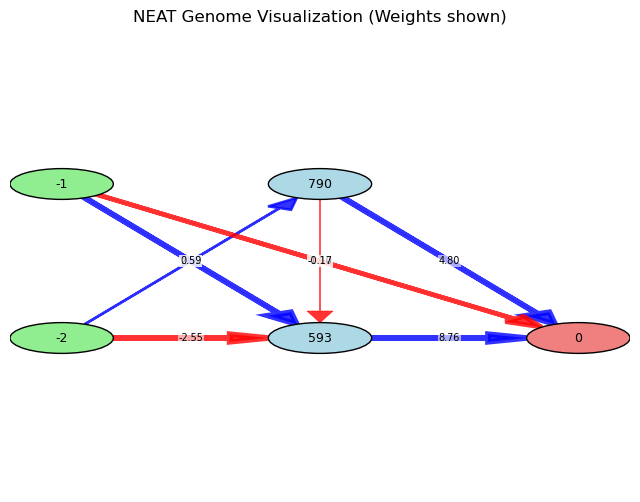

In [42]:
nodes = list(winner.nodes.keys())
connections = [cg for cg in winner.connections.values() if cg.enabled]

input_nodes = config.genome_config.input_keys
output_nodes = config.genome_config.output_keys
hidden_nodes = [n for n in nodes if n not in input_nodes and n not in output_nodes]

node_positions = {}
for i, node in enumerate(sorted(input_nodes)):
    node_positions[node] = (0, i)
for i, node in enumerate(sorted(output_nodes)):
    node_positions[node] = (1, i)
for i, node in enumerate(sorted(hidden_nodes)):
    node_positions[node] = (0.5, i)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-0.1, 1.1)
max_y = max(len(input_nodes), len(output_nodes), len(hidden_nodes))
ax.set_ylim(-1, max_y)

# Draw nodes
for node, (x, y) in node_positions.items():
    if node in input_nodes:
        color = 'lightgreen'
    elif node in output_nodes:
        color = 'lightcoral'
    else:
        color = 'lightblue'

    circle = plt.Circle((x, y), 0.1, color=color, ec='black', zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, str(node), ha='center', va='center', zorder=4, fontsize=9)

# Draw connections with weight styling
for conn in connections:
    start = node_positions[conn.key[0]]
    end = node_positions[conn.key[1]]

    dx = end[0] - start[0]
    dy = end[1] - start[1]
    length = (dx**2 + dy**2)**0.5
    if length == 0:
        continue

    offset_x = 0.1 * dx / length
    offset_y = 0.1 * dy / length

    # Style by weight
    weight = conn.weight
    linewidth = max(0.5, min(abs(weight)*3, 4))  # thickness proportional to weight
    if weight > 0:
        color = (0, 0, 1, min(1, abs(weight)))  # blue with alpha scaled by weight
    else:
        color = (1, 0, 0, min(1, abs(weight)))  # red with alpha scaled by weight

    ax.arrow(start[0] + offset_x, start[1] + offset_y,
             dx - 2 * offset_x, dy - 2 * offset_y,
             head_width=0.05, length_includes_head=True,
             fc=color, ec=color, linewidth=linewidth, alpha=0.8)

    # Show weight value as text near middle of the arrow
    mid_x = start[0] + dx / 2
    mid_y = start[1] + dy / 2
    ax.text(mid_x, mid_y, f"{weight:.2f}", fontsize=7, ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.5))

ax.axis('off')
plt.title('NEAT Genome Visualization (Weights shown)')
plt.show()


Provided you can define inputs and outputs and a fitness function, NEAT can be used for any problem. I have used it to train a model to play blackjack for example.

What is key is your fitness function scales well, for example, if we train a model to play Mario, we should not reward based on number of stages cleared, if so, it will probably never clear stage 1. Instead, we should train on something we can incrementally improve, like number of tiles moved forwards.

Because of the incremental nature of NEAT, it makes for some [excellent YouTube videos](https://www.youtube.com/watch?v=qv6UVOQ0F44).


# Recap
* What is a neural network?
* How do neural networks relate to vectors and matrices?
* What options do we have for training neural networks?
* What libraries can we use?
* What are genetic algorithms?

# Homework
Try training your own neural networks, both to solve traditional data science problems, like [The Titanic Problem](https://www.kaggle.com/competitions/titanic), but also games, like Blackjack.